# Tutorial_2_Make_a_Spectrum

This tutorial walks you through generating a synthetic spectrum by manipulating the model parameters.

In [1]:
from pathlib import Path
import os
import sys

# Use one working directory for Brewster imports and repository data paths.
project_root = Path.cwd().resolve()
for candidate in (project_root, *project_root.parents):
    if (candidate / "utils.py").is_file() and (candidate / "retrieval_run.py").is_file():
        project_root = candidate
        break
else:
    raise FileNotFoundError("Start this notebook from within the Brewster repository.")

os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
print("Brewster repository:", project_root)

Brewster repository: /Users/fw23aao/spidernail/brewster_trail/v2_master/brewster_v2


In [2]:
import os 
import test_module
from collections import namedtuple
import numpy as np
import retrieval_run
import settings
import cloud_dic
import utils
import test_module
import brewtools
import matplotlib.pyplot as plt
from specops import proc_spec




## 1. Define All Class Setups:
Instrument, ModelConfig, IOConfig, Retrieval_params, and ArgsGen.

In [3]:
# instrument
wavelength_range=[1,2.49]
ndata=1
Rfile='./examples/example_data/G570D_R_file.txt'
obspec = np.asfortranarray(np.loadtxt("./examples/example_data/G570D_2MHcalib.dat",dtype='d',unpack='true')) # G570D_2MassJcalib.dat


## gas
chemeq=0
# gaslist = ['h2o','co','tio','vo','crh','feh','na','k']
gaslist = ['h2o','ch4']
gastype_list=['U','U']

# PT structure
ptype=7  

## clouds

cloud_dir = (project_root / "../../cloud_pickles").resolve()

do_clouds=1
npatches=1
cloud_name=['MgSiO3.mieff'] #Mg2SiO4 MgSiO3
cloud_type=["slab"]
particle_dis=["hansen"] #"hansen" "log_normal"
cloudpatch_index=[[1]]


# ModelConfig:
do_fudge=1
samplemode='mcmc'


instrument_instance = utils.Instrument(wavelength_range=wavelength_range, R_file=Rfile,obspec=obspec)
re_params = utils.Retrieval_params(samplemode,chemeq,gaslist,gastype_list,do_fudge,ptype,do_clouds,npatches,cloud_name,cloud_type,cloudpatch_index,particle_dis,instrument_instance,fwhm=None)

model_config_instance = utils.ModelConfig(
      samplemode,
      do_fudge,
      cloudpath=str(cloud_dir) + os.sep,
      cia_path=str(project_root / "data/CIA_DS_aug_2015.dat"),
      chem_eq_table_path=str(project_root / "data/chem_eq_tables_P3K.pic"),
  )

# model_config_instance = utils.ModelConfig(samplemode,do_fudge,cloudpath=cloudpath)
io_config_instance = utils.IOConfig()

model_config_instance.dist= 5.84
model_config_instance.xlist ='data/gaslistRox.dat'
model_config_instance.xpath ='../../Linelists/'
model_config_instance.do_bff=1
model_config_instance.malk=0
model_config_instance.ch4=0
model_config_instance.update_dictionary()

## 2. Generate the Args Instance
Load the opacity data (line lists and cia) and cloud data to prepare for the forward model.

In [4]:
args_instance = utils.ArgsGen(re_params,model_config_instance,instrument_instance,obspec)
settings.init(args_instance)
settings.cia = args_instance.cia
settings.linelist= utils.get_opacities(args_instance.gaslist,args_instance.w1,args_instance.w2,args_instance.press,args_instance.xpath,args_instance.xlist,args_instance.malk)
settings.cloudata = args_instance.cloudata

## 3 check all model parameters

In [5]:
args_instance=settings.runargs
all_params,all_params_values =utils.get_all_parametres(re_params.dictionary)
print(all_params)
print(all_params_values)

['h2o', 'ch4', 'logg', 'r2d2', 'dlambda', 'tolerance_parameter_1', 'Tint', 'alpha', 'lndelta', 'T1', 'T2', 'T3', 'tau_mcs_MgSiO3', 'logp_mcs_MgSiO3', 'dp_mcs_MgSiO3', 'hansen_a_mcs_MgSiO3', 'hansen_b_mcs_MgSiO3']
[None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None]


## 4. Initialize the Retrieval Parameters
Here we use the default parameter distributions and create a random initialization.


In [9]:
all_params,all_params_values =utils.get_all_parametres(re_params.dictionary)

if re_params.samplemode=='mcmc':
    
    model_config_instance.ndim=len(all_params)
    model_config_instance.nwalkers=len(all_params)*16

    r2d2 = (71492e3)**2. / (model_config_instance.dist * 3.086e+16)**2.
    re_params.dictionary['refinement_params']['params']['r2d2']['MC_init_dis']=['normal',r2d2,0.1*r2d2]


    def tolerance_parameter_customized_distribution(x):
        return np.log10((np.random.rand(x)* (max(args_instance.obspec[2,:]**2)*(0.1 - 0.01))) + (0.01*min(args_instance.obspec[2,10::3]**2))) 

    for i in range(len(all_params)):
        if all_params[i].startswith('tolerance_parameter'):
            re_params.dictionary['refinement_params']['params'][all_params[i]]['MC_init_dis']=['customized',tolerance_parameter_customized_distribution]

    if model_config_instance.fresh == 0:
        p0=utils.MC_P0_gen(re_params.dictionary,model_config_instance,args_instance)

### 4.1 Create a Parameter Instance 
wrap the initialized values into a convenient namedtuple structure for use with the forward model.

In [10]:
params_master = namedtuple('params',all_params)
params_instance = params_master(*p0[0,:])
params_instance

params(h2o=-4.1948490558157125, ch4=-4.6494382003528845, logg=4.363722240793668, r2d2=1.4671828694835744e-19, dlambda=0.001080464182437598, tolerance_parameter_1=-32.43548965630922, Tint=1354.3234926348414, alpha=1.399515760196567, lndelta=1.0592735102833233, T1=1088.2883410896088, T2=1315.36261995784, T3=1010.139899119245, tau_mcs_MgSiO3=11.16576267290279, logp_mcs_MgSiO3=-0.18073267766450712, dp_mcs_MgSiO3=0.007699189322490094, hansen_a_mcs_MgSiO3=-1.4729299868568004, hansen_b_mcs_MgSiO3=0.22093760908564775)

### 4.2. You Can Also Manually Adjust Parameter Values

In [11]:
params_instance = params_instance._replace(h2o=-4)
params_instance = params_instance._replace(ch4=-5)
params_instance

params(h2o=-4, ch4=-5, logg=4.363722240793668, r2d2=1.4671828694835744e-19, dlambda=0.001080464182437598, tolerance_parameter_1=-32.43548965630922, Tint=1354.3234926348414, alpha=1.399515760196567, lndelta=1.0592735102833233, T1=1088.2883410896088, T2=1315.36261995784, T3=1010.139899119245, tau_mcs_MgSiO3=11.16576267290279, logp_mcs_MgSiO3=-0.18073267766450712, dp_mcs_MgSiO3=0.007699189322490094, hansen_a_mcs_MgSiO3=-1.4729299868568004, hansen_b_mcs_MgSiO3=0.22093760908564775)

## 5. Run the Forward Model to Generate a Spectrum
feed the state vector to forward model 

In [12]:
gnostics = 0
trimspec, photspec, tauspec,cfunc = test_module.modelspec(params_instance,re_params,args_instance,gnostics)

<module 'matplotlib.pyplot' from '/Users/fw23aao/anaconda3/lib/python3.11/site-packages/matplotlib/pyplot.py'>

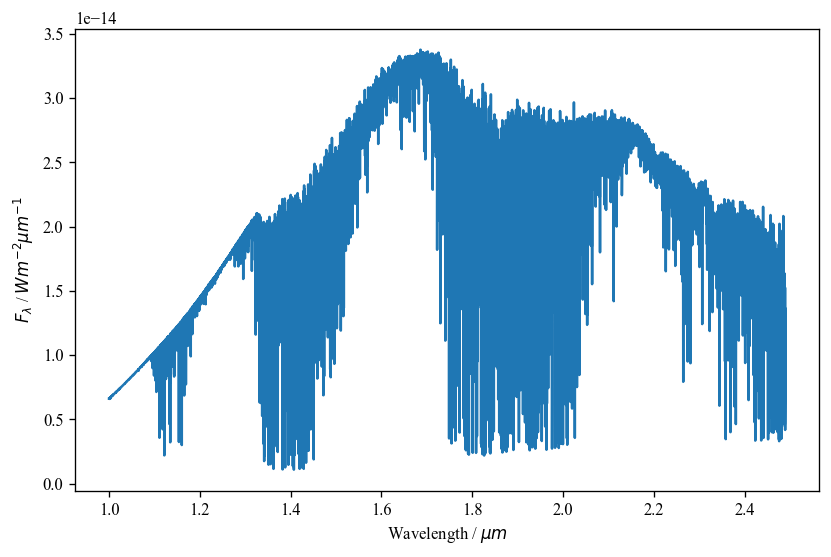

In [13]:
# plot the spectra
plt.rc('font',family='Times New Roman')
fig=plt.figure(dpi=120,figsize=[8,5])
ax=fig.add_subplot(111)
ax.plot(trimspec[0,:],trimspec[1,:])
plt.ylabel(r'$ F_{\lambda}$ / $Wm^{-2} \mu m^{-1}$')
plt.xlabel('Wavelength / $\mu m$')
plt


<module 'matplotlib.pyplot' from '/Users/fw23aao/anaconda3/lib/python3.11/site-packages/matplotlib/pyplot.py'>

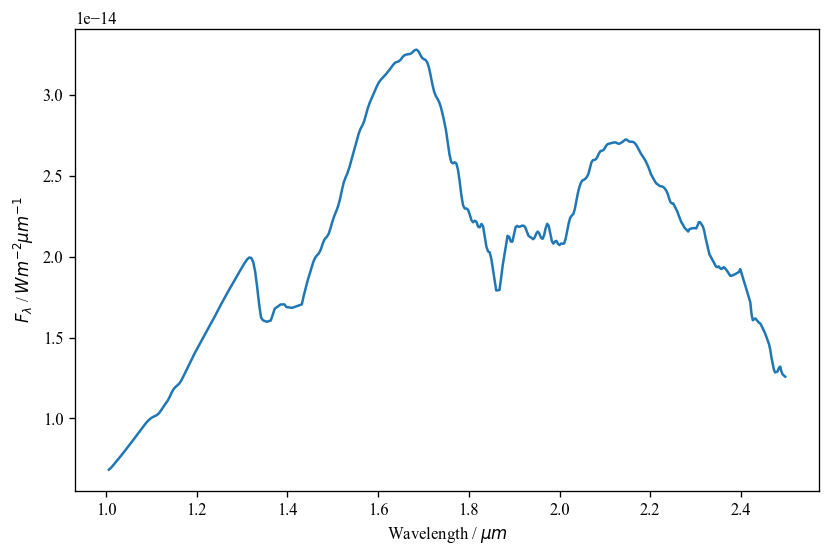

In [14]:
wave,topspec=proc_spec(inputspec=trimspec, theta=params_instance, re_params=re_params, args_instance=args_instance, do_scales=args_instance.do_scales, do_shift=args_instance.do_shift)

# plot the convolved spectra
plt.rc('font',family='Times New Roman')
fig=plt.figure(dpi=120,figsize=[8,5])
ax=fig.add_subplot(111)
ax.plot(wave,topspec)
plt.ylabel(r'$ F_{\lambda}$ / $Wm^{-2} \mu m^{-1}$')
plt.xlabel('Wavelength / $\mu m$')
plt